# Black Friday Customer Purchase Prediction & Sales Analysis



The objective of this project is to predict the purchase amount of customers during Black Friday sales using machine learning techniques. By analyzing customer demographics, product categories, and purchasing behavior, we aim to identify the factors that influence spending and build an accurate prediction model.

### Import Libraries

**Interpretation**

In this step, we import the required Python libraries for data manipulation, visualization, preprocessing, model building, and evaluation. Pandas and NumPy are used for handling data, while Matplotlib and Seaborn are used for visualization. Scikit-learn provides machine learning algorithms and evaluation metrics.

In [6]:
#Importing Libraries:

#Import Pandas Library and make it as pd:
import pandas as pd

#Import NumPy Library and make it as np:
import numpy as np

#Import PyPlot from Matplotlib Library and make it as plt:
import matplotlib.pyplot as plt

#Import Seaborn Library and make it as sns:
import seaborn as sns 

#Inorder to Supress Warnings import Filterwarnings:
from warnings import filterwarnings
filterwarnings('ignore')

### Load Dataset

**Interpretation**

The dataset is loaded into a Pandas DataFrame. To reduce computational time and memory usage, a random sample of 50,000 records is selected from the original dataset while maintaining reproducibility using a fixed random state.

In [23]:
# Load the dataset

df = pd.read_csv("BlackFriday.csv")
df = df.sample(n=50000, random_state=42)
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
84432,1001062,P00351342,M,51-55,19,C,3,0,1,2.0,16.0,19142
72724,1005172,P00237542,F,36-45,11,B,1,0,1,15.0,16.0,15513
197032,1000415,P00116242,F,36-45,0,A,2,1,8,15.0,NaN,7802
353704,1000496,P00016742,M,18-25,4,A,3,0,1,15.0,16.0,15455
91198,1002010,P00002242,M,18-25,4,B,0,0,6,8.0,16.0,4492
...,...,...,...,...,...,...,...,...,...,...,...,...
433387,1000746,P00051142,F,18-25,19,B,3,0,8,NaN,NaN,7813
332280,1003231,P00153842,M,26-35,7,A,1,1,8,14.0,16.0,9758
93247,1002331,P00209842,M,55+,1,A,1,1,5,8.0,NaN,8665
89843,1001835,P00111942,M,26-35,19,B,3,0,8,17.0,NaN,9700


In [25]:
# The first few records are displayed to understand the structure of the dataset, feature names, and data format.
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
84432,1001062,P00351342,M,51-55,19,C,3,0,1,2.0,16.0,19142
72724,1005172,P00237542,F,36-45,11,B,1,0,1,15.0,16.0,15513
197032,1000415,P00116242,F,36-45,0,A,2,1,8,15.0,NaN,7802
353704,1000496,P00016742,M,18-25,4,A,3,0,1,15.0,16.0,15455
91198,1002010,P00002242,M,18-25,4,B,0,0,6,8.0,16.0,4492


In [27]:
# Last five rows of the dataset
df.tail()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
433387,1000746,P00051142,F,18-25,19,B,3,0,8,NaN,NaN,7813
332280,1003231,P00153842,M,26-35,7,A,1,1,8,14.0,16.0,9758
93247,1002331,P00209842,M,55+,1,A,1,1,5,8.0,NaN,8665
89843,1001835,P00111942,M,26-35,19,B,3,0,8,17.0,NaN,9700
172319,1002654,P00143842,F,36-45,9,C,0,1,5,14.0,NaN,8819


In [29]:
# The shape of the dataset helps us identify the number of observations and features available for analysis.
df.shape

(50000, 12)

In [31]:
# This provides information about data types, non-null values, and memory usage.
# It helps identify categorical variables and columns containing missing values.

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 84432 to 172319
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     50000 non-null  int64  
 1   Product_ID                  50000 non-null  object 
 2   Gender                      50000 non-null  object 
 3   Age                         50000 non-null  object 
 4   Occupation                  50000 non-null  int64  
 5   City_Category               50000 non-null  object 
 6   Stay_In_Current_City_Years  50000 non-null  object 
 7   Marital_Status              50000 non-null  int64  
 8   Product_Category_1          50000 non-null  int64  
 9   Product_Category_2          34346 non-null  float64
 10  Product_Category_3          15339 non-null  float64
 11  Purchase                    50000 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 5.0+ MB


In [33]:
# It displays all columns data types for better to do encoding
df.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

In [35]:
# Summary statistics are generated for numerical features to understand their distribution, central tendency, and variability.
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.000000e+04,50000.000000,50000.000000,50000.000000,34346.000000,15339.000000,50000.00000
mean,1.003022e+06,8.131780,0.409700,5.397600,9.853054,12.630550,9261.56782
std,1.731794e+03,6.532686,0.491783,3.927536,5.095448,4.163118,5013.92918
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.00000
25%,1.001505e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5796.00000
50%,1.003062e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8042.50000
75%,1.004480e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12041.25000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.00000


### Data Cleaning

In [40]:
# Check missing values

df.isnull().sum()

User_ID                           0
Product_ID                        0
Gender                            0
Age                               0
Occupation                        0
City_Category                     0
Stay_In_Current_City_Years        0
Marital_Status                    0
Product_Category_1                0
Product_Category_2            15654
Product_Category_3            34661
Purchase                          0
dtype: int64

**Interpretation**

Missing values are identified to determine which features require preprocessing. Product_Category_2 and Product_Category_3 contain missing values because not every product belongs to a second or third category.

In [42]:
# Fill Missing Values

df["Product_Category_2"] = df["Product_Category_2"].fillna(0)

df["Product_Category_3"] = df["Product_Category_3"].fillna(0)

**Interpretation**

Missing values in Product_Category_2 and Product_Category_3 are replaced with 0. This indicates the absence of a secondary or tertiary product category rather than an unknown value.

In [46]:
# Sanitary check for missing values

df.isnull().sum().sum()

0

In [48]:
# Check Duplicates

df.duplicated().sum()

0

**Interpretation**

Duplicate records are checked to ensure data quality. Duplicate entries can bias model performance and should be removed if present.

### Feature Engineering

In [51]:
# Gender Encoding 

df['Gender'] = df['Gender'].map({'M':1,'F':0})

**Interpretation**

Machine learning models cannot process textual categories directly. Therefore, Gender is converted into numerical values using label encoding.

In [53]:
df['Age'].unique()

array(['51-55', '36-45', '18-25', '26-35', '0-17', '55+', '46-50'],
      dtype=object)

In [55]:
# Importing LabelEncoder from sklearn library
from sklearn.preprocessing import LabelEncoder

In [57]:
le = LabelEncoder()
df['Age'] = le.fit_transform(df['Age'])

**Interpretation**

Age groups are transformed into numerical values while preserving their natural order. This allows the model to utilize age-related purchasing patterns.

In [59]:
# City Category Encoding

df['City_Category'] = le.fit_transform(df['City_Category'])

In [61]:
# Stay In Current City Years 

df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].replace('4+','4')

df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)

**Interpretation**

City categories are encoded into numerical values so that machine learning algorithms can interpret them.

### Drop Unnecessary Columns

In [68]:
df.drop(['User_ID','Product_ID'], axis=1, inplace=True)

**Interpretation**

User_ID and Product_ID are unique identifiers and do not contribute meaningful predictive information. Therefore, they are removed to prevent unnecessary complexity.

In [70]:
df.head(1)

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
84432,1,5,19,2,3,0,1,2.0,16.0,19142


### Exploratory Data Analysis (EDA)

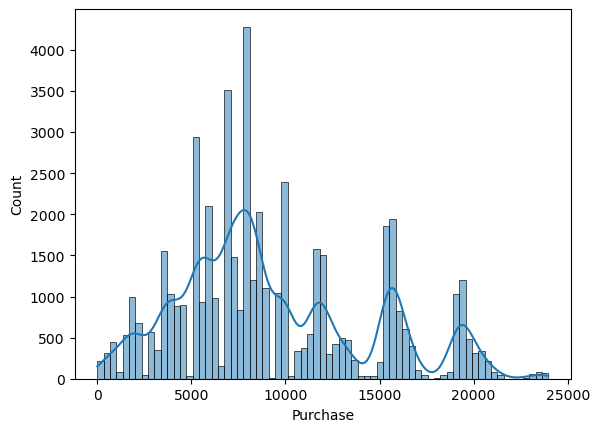

In [73]:
# Histogram for purchase column
sns.histplot(df['Purchase'], kde=True)

#Displays the plot
plt.show()

**Interpretation**

The distribution of purchase amounts is analyzed to understand customer spending behavior. This helps identify skewness, potential outliers, and overall spending trends.

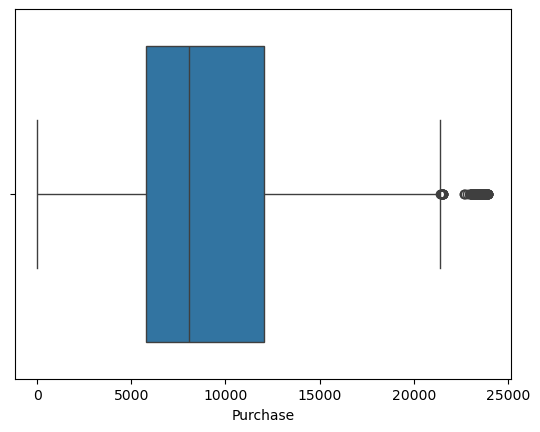

In [83]:
# Boxplot for detecting Outliers 
sns.boxplot(x='Purchase',data=df)

#Displays the plot
plt.show()

**Interpretation**

Purchase column have outliers but we don't remove them as that customers purchase is genuine we can't remove the high paying customers

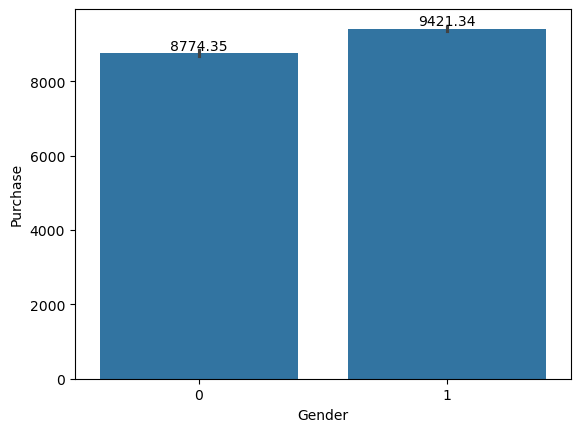

In [77]:
# Using barplot for total purchase by gender
ax = sns.barplot(x='Gender', y='Purchase', data = df)
ax.bar_label(ax.containers[0])

#Displays the plot
plt.show()

**Interpretation**

The average purchase amount is compared across genders to understand whether spending behavior differs between male and female customers.

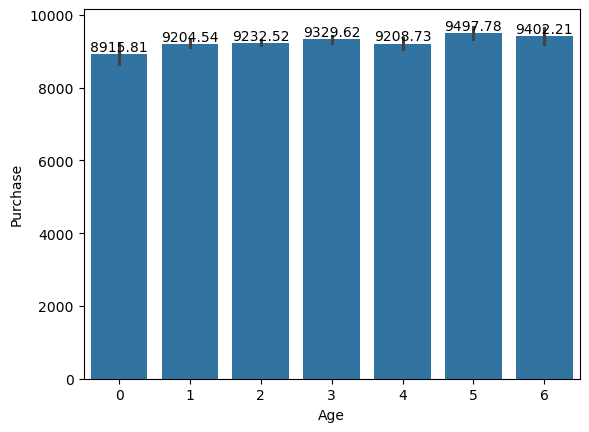

In [79]:
# Barplot for total purchase by age
ax = sns.barplot(x='Age', y='Purchase', data = df)
ax.bar_label(ax.containers[0])

#Displays the plot
plt.show()

**Interpretation**

This analysis helps identify which age groups contribute the most to overall sales and spending.

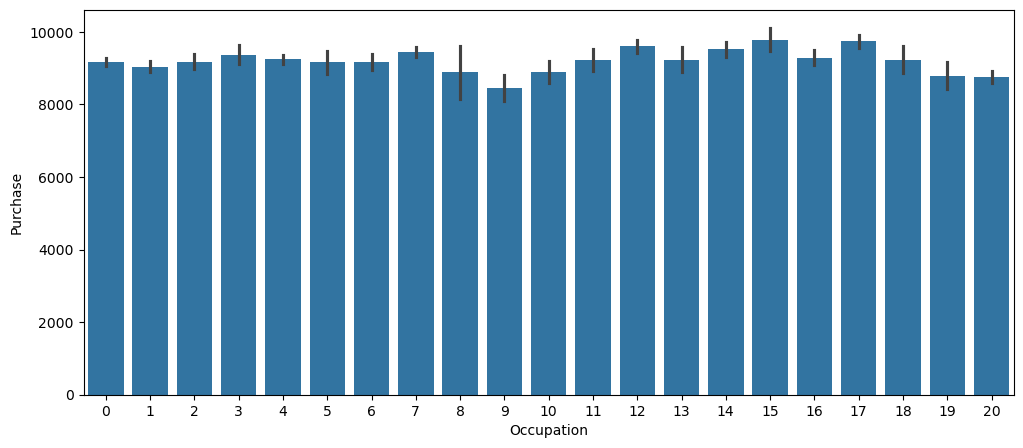

In [85]:
# Gives the plot size
plt.figure(figsize = (12,5))

ax = sns.barplot(x = 'Occupation', y='Purchase', data = df)

#Displays the plot
plt.show()

**Interpretation**

Customer spending patterns are analyzed across different occupations to determine whether occupation influences purchase behavior.

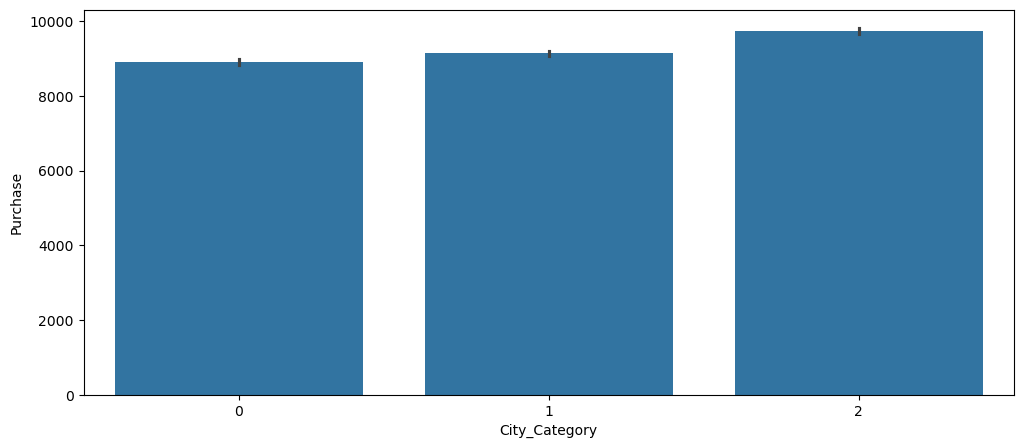

In [87]:
# Sets the figure size
plt.figure(figsize = (12,5))

ax = sns.barplot(x = 'City_Category', y='Purchase', data = df)

# Displays the plot
plt.show()

**Interpretation**

The relationship between city category and purchase amount is examined to identify geographical differences in customer spending.

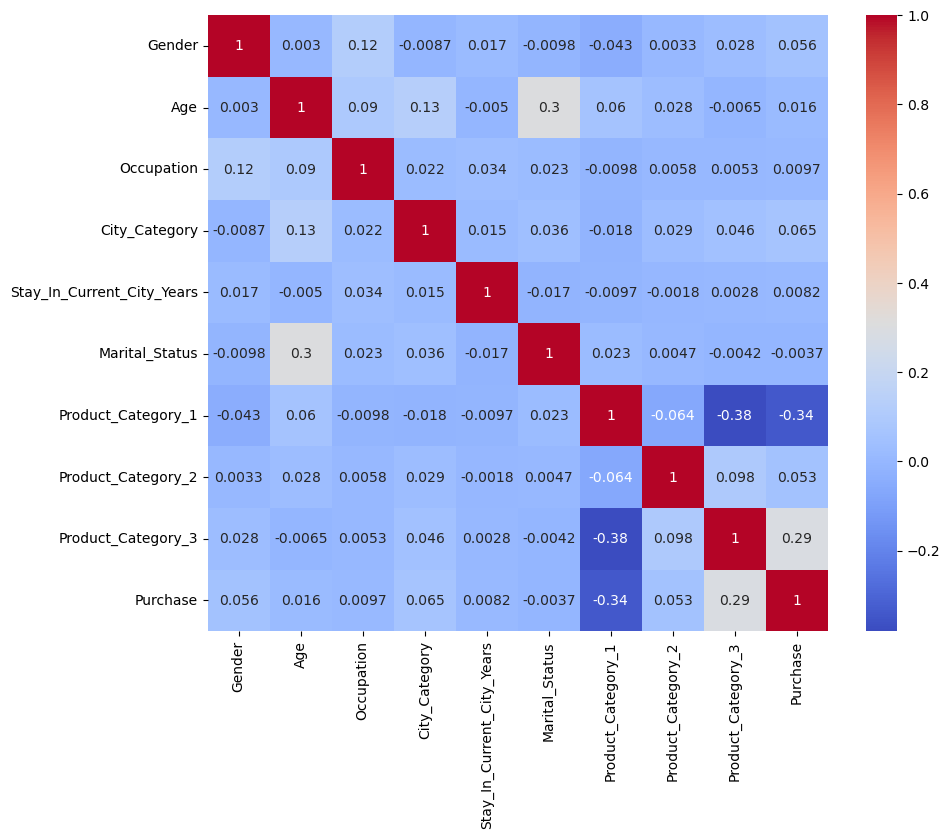

In [89]:
# Heat Map for Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

#Displays the plot
plt.show()

**Interpretation**

A correlation matrix is used to measure the strength and direction of relationships between numerical variables. This helps identify potentially important features for prediction.

### Model Building


#### Feature and Target Separation

In [91]:
# Feature columns
X = df.drop('Purchase', axis=1)

# Target Column
Y = df['Purchase']

**Interpretation**

The dataset is divided into independent variables (features) and the dependent variable (Purchase). The target variable represents the purchase amount to be predicted.

### Train-Test Split

In [93]:
# Importing train_test_split module  from sklearn library
from sklearn.model_selection import train_test_split

In [95]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,
                                                   random_state=42)

print('X_train : ', x_train.shape)
print('X_test : ', x_test.shape)
print('Y_train : ', y_train.shape)
print('Y_test : ', y_test.shape)

X_train :  (40000, 9)
X_test :  (10000, 9)
Y_train :  (40000,)
Y_test :  (10000,)


**Interpretation**

The dataset is divided into training and testing sets. The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

### Feature Scaling

In [97]:
 from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Interpretation**

Feature scaling is applied before Linear Regression to standardize feature values and improve model performance. Tree-based models such as Decision Tree, Random Forest, and Gradient Boosting do not require scaling.

### Train Linear Regression

In [100]:
# Importing LinearRegression Model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_test_scaled)


**Interpretation**

Linear Regression is used as a baseline model. It assumes a linear relationship between features and the target variable and provides a benchmark for comparison with more advanced algorithms.

### Train Decision Tree

In [103]:
# Importing Decision Tree Model
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor( random_state=42)

dt.fit(x_train,y_train)

y_pred_dt = dt.predict(x_test)

**Interpretation**

Decision Tree Regressor captures nonlinear relationships by recursively splitting the data into smaller subsets based on feature values.

### Train Random Forest

In [106]:
#Importing Random Forest Model
from sklearn.ensemble import RandomForestRegressor 

rf = RandomForestRegressor(
    n_estimators =100,
    random_state =42,
    n_jobs =-1
)

rf.fit(x_train,y_train)

y_pred_rf = rf.predict(x_test)


**Interpretation**

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting through ensemble learning.

### Train Gradient Boosting

In [109]:
# Importing Gradient Boosting Model
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(x_train,y_train)

y_pred_gb = gb.predict(x_test)

**Interpretation**

Gradient Boosting builds trees sequentially, where each tree attempts to correct the errors of the previous one. This often results in superior predictive performance.

### Model Evaluation

In [112]:
# Importing Metrics 
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


**Interpretation**

Three evaluation metrics are used:

1. R² Score - Measures the proportion of variance explained by the model.
2. MAE - Measures the average absolute prediction error.
3. RMSE - Penalizes larger prediction errors more heavily.


In [114]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})

comparison.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
3,Gradient Boosting,0.638944,2274.343236,3008.510718
2,Random Forest,0.589745,2349.982270,3206.942495
1,Decision Tree,0.376090,2773.137324,3954.805186
0,Linear Regression,0.160215,3532.335873,4588.263933


**Interpretation**

Among all evaluated models, Gradient Boosting Regressor achieved the highest R² Score (0.639), the lowest MAE, and the lowest RMSE. Therefore, it was selected as the final model for this project.

In [118]:
print("Gradient Boosting Train Score:",
      gb.score(x_train, y_train))

print("Gradient Boosting Test Score:",
      gb.score(x_test, y_test))

Gradient Boosting Train Score: 0.6423110509289736
Gradient Boosting Test Score: 0.6389439670892797


**Interpretation**

The training and testing R² scores were compared to assess model generalization. The minimal difference between the two scores indicates that the model generalizes well and does not suffer from significant overfitting.


In [120]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
6,Product_Category_1,0.975485
8,Product_Category_3,0.008693
7,Product_Category_2,0.008007
3,City_Category,0.004686
1,Age,0.001588
2,Occupation,0.001143
4,Stay_In_Current_City_Years,0.000330
0,Gender,0.000065
5,Marital_Status,0.000003


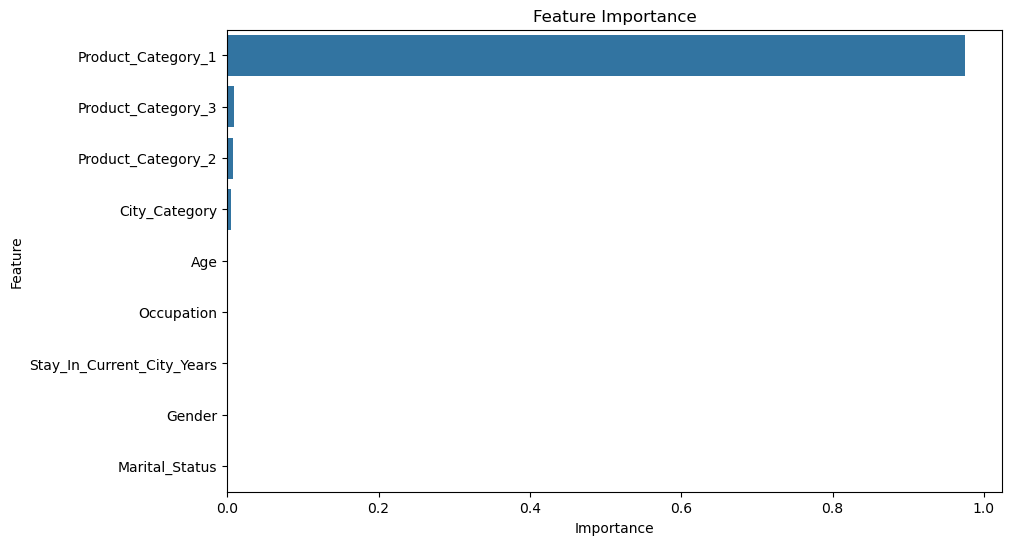

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.sort_values(
        by="Importance",
        ascending=False
    ),
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

### Project Conclusion

- Developed a Black Friday Sales Prediction model using multiple regression algorithms including Linear Regression, Decision Tree, Random Forest, and Gradient Boosting.
-  After comparing models using R² Score, MAE, and RMSE, Gradient Boosting Regressor achieved the best performance with an R² score of 0.639 and showed excellent generalization with minimal train-test performance gap.
-  The project involved data cleaning, missing value handling, feature engineering, EDA, model comparison, and hyperparameter tuning.

### Business Recommendations

1. Focus marketing campaigns on customer segments with higher predicted purchase amounts.

2. Personalize offers based on age groups and product categories.

3. Optimize inventory planning for high-demand product categories.

4. Use predictive insights during festive seasons to improve sales forecasting.

5. Design targeted promotions for customer groups with lower spending behavior.